<font size="3">**Tarea 3**</font>

<u> *Instrucciones* </u>

Los resultados de los ejericicios propuestos se deben entregar como un notebook por correo electronico a *juancaros@udec.cl* el dia 9/6 hasta las 21:00. Es importante considerar que el código debe poder ejecutarse en cualquier computadora con la data original del repositorio. Recordar la convencion para el nombre de archivo ademas de incluir en su documento titulos y encabezados por seccion. Utilizar la base de datos junaeb2.csv, el diccionario de datos es el siguiente:

- sexo: sexo del estudiante (1: mujer)
- edad: edad del estudiante (meses)
- imce: indice de masa corporal estandarizado (puntaje z)
- vive_padre: 1 si el padre vive en el hogar (2 indica que tiene mas de un padre)
- vive_madre: 2 si la madre vive en el hogar (2 indica que tiene mas de una madre)
- area: urbana=1, rural=0
- sk1: muestra afecto a padres (1: siempre - 5: nunca)
- sk2: muestra afecto a sus pares (1: siempre - 5: nunca)
- sk3: expresa sus sentimientos (1: siempre - 5: nunca)
- sk4: usa gestos para mostrar sentimientos (1: siempre - 5: nunca)
- sk5: juega con otros (1: siempre - 5: nunca)
- sk6: comparte sus cosas con otros (1: siempre - 5: nunca)
- sk7: es agresivo (1: siempre - 5: nunca)
- sk8: participa en juegos grupales (1: siempre - 5: nunca)
- sk9: hace preguntas a adultos (1: siempre - 5: nunca) 
- sk10: tiene interes por libros (1: siempre - 5: nunca) 
- sk11: tiene interes por su entorno (1: siempre - 5: nunca)
- sk12: juega a armar y desarmar cosas (1: siempre - 5: nunca) 
- sk13: tiene expresiones artisticas (1: siempre - 5: nunca) 
- act_fisica: frecuencia actividad fisica (1: nunca - 5: 5 o mas veces a la semana)
- educm: años de escolaridad de la madre
- educp: años de escolaridad del padre
- madre_work: si la madre trabaja (-1: labor domestica, 0: desempleada, 1: empleada)

Preguntas
1. Cargue la base de datos y realice los ajustes necesarios para su uso (missing values, recodificar variables, etcetera). Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.
2. A partir de las variables sk1-sk13 realice un EFA. En particular determine el numero optimo de factores y reporte las variables que se asocian a cada factor (usando los factor loadings). Tambien discuta si existen variables que no son informativas. (Hint: para realizar un EFA, todas las variables deben estar representatadas en el mismo sentido logico. Si una carateristica es negativa debe ser invertida en la escala, de tal forma que todas las variables representen aspectos positivos).
3. Con los resultados de la Pregunta 2, graficamente indique si existen diferencias significativas en la distribucion de los factores usando las siguientes variables para caracterizar: sexo, area, imce y act_fisica (Hint: usar scatterplot de factores en pares, y ocupar la opcion 'hue' para agregar variables de caracterizacion). Que puede concluir de los resultados?
4. Con los resultados obtenidos en la Pregunta 2, proponga un CFA donde cada variable solo se asocia con un factor. Entregue un nombre a cada factor que representa el concepto comun entre las variables incluidas. Reporte la importancia de cada medida (variable) a cada factor e indique la correlacion entre factores (loadings). 
5. Estime un modelo de clases latentes usando imce via StepMix. Determine el numero optimo de clases (clusters) y muestre las diferencias entre clusters graficamente. Que se puede concluir de los resultados?
6. Implemente un SEM completo usando la estructura propuesta en la Pregunta 4. En particular, estime un modelo donde los factores latentes explican el imce, junto con otras variables que existen en la base de datos. Ademas utilice otras variables relevantes de la base de datos para su modelo. Las variables a incluir en el modelo final deben tener sustento teorico y el modelo final debe optimizar el ajuste a los datos, en base a los criterios vistos en clase (TLI, CLI, RMSEA). Que puede concluir en base a sus resultados?
7. Repita el analisis de la Pregunta 6 usando para cada submuestra generada a partir de las clases latentes obtenida en la pregunta 5. Reporte diferencias entre los parametros entre los distintos grupos (si existieran). Hay alguna ganancia de estimar el modelo por grupos versus el modelo general?  

Pregunta 1:
R:Se realizaron gráficos y no se observaron valores atípicos, solo se detectaron valores NaN, los cuales fueron eliminados. Además, en paralelo noté que la variable SK7 no tenía la misma escala que las demás, por lo que la invertí y realicé los análisis correspondientes. Como conclusión, determiné que no era significativo incluirla, por lo cual se decidió eliminarla del dataframe que se iba a utilizar. Este procedimiento está documentado en la parte 1.

Pregunta 2:
**R:**  
Para determinar el número óptimo de factores, se utilizaron los **valores propios**. Sabemos que si un valor propio no supera 1, el factor asociado no es significativo. De este criterio se deduce el número de factores relevantes.  

En nuestro caso (como se observa en la parte 2), solo **3 valores propios resultaron significativos**, por lo que se utilizaron únicamente 3 factores.  

Posteriormente, mediante la función `get_loadings`, identificamos las siguientes relaciones:  
- **Factor 2**: Variables `sk1` a `sk4` (asociación predominante).  
- **Factor 3**: Variables `sk5`, `sk6` y `sk8` (asociación principal).  
- **Factor 1**: Variables `sk9` a `sk13` (asociación mayoritaria).  

nuestro criterio para afirmar esto es que si fuera el loadin de la variable relacionada al factor fuera mayor de 0.45 aproximidamente,ya que cuando veiamos que no estaban muy relacionados siempre era por de bajo de ese numero 

Luego se corrio semopy . efa . explore_cfa_model,el cual confirmo nuestas interpretacion pero con ciertas diferencias.


Pregunta 3:
**R:**  
Podemos notar gráficamente que no hay diferencias entre las distribuciones de los factores y las variables solicitadas. Esto se encuentra documentado en la Parte 2. Una posible razón de esta situación es que, al modelo EFA, cuando se le solicitó calcular los factores, no se le entregaron específicamente las variables requeridas. Por lo tanto, al no disponer de esa información, el modelo no pudo diferenciarlas correctamente. En cambio, si realizáramos una comparación de la distribución de factores para una variable específica, como `sk`, en ese caso sí observaríamos una diferencia, ya que los factores fueron calculados considerando esa variable.



Pregunta 4:

**R:**  
## Modelo propuesto
eta1 =~ sk9 + sk10 + sk11 + sk12 + sk13  # Factor 1: Desarrollo Cognitivo y Exploratorio  
eta2 =~ sk1 + sk2 + sk3 + sk4            # Factor 2: Expresión Emocional y Afectiva  
eta3 =~ sk5 + sk6 + sk8                  # Factor 3: Habilidades Sociales y Cooperación
### Resultados de Ajuste del Modelo

**NFI (Normed Fit Index):** > 0.8  
- Cumple con criterios de bondad de ajuste (valores > 0.8 considerados aceptables).  

**RMSEA (Root Mean Square Error of Approximation):** 0.053  
- Ligeramente superior al umbral ideal de 0.05, pero dentro de rangos aceptables según estándares.  
- Interpretación:  
  - 0.05-0.08: Error de aproximación razonable.  
  - < 0.05: Ajuste óptimo.  

El análisis se basó en los resultados de la pregunta 2 (parte 4), donde se observó la relación entre variables y factores. Los factores identificados fueron: eta1 (desarrollo cognitivo y exploratorio), eta2 (expresividad emocional y afectiva) y eta3 (habilidades sociales y cooperación). El modelo mostró buenos resultados, con un NFI > 0.8 (cumpliendo el criterio discutido en clases) y un RMSEA de 0.053 (ligeramente superior a 0.05 pero aún dentro del rango aceptable), lo que indica que el modelo es estadísticamente significativo.

En cuanto a las correlaciones, todas las variables mostraron relaciones significativas (*p* < 0.05) con sus factores respectivos, excepto SK1 con eta1 y SK5 con eta3, donde no se encontró asociación significativa. Aunque el modelo no reportó los valores *p* específicos para estas dos correlaciones, el resto de las variables sí presentaron valores *p* menores a 0.05, confirmando su vinculación con los factores asignados.Igualmente se decidio seguir con el modelo propuesto por sus buneos resultados.



Pregunta 5:
**R:** 

Como se muestra en la Parte 5, se realizó un gráfico de BIC para determinar el número óptimo de clústeres para la variable **IMCE**. A partir de este gráfico, se concluyó que existían dos opciones viables: **4 clústeres** o **3 clústeres**, ya que en ambos casos el BIC alcanzaba su valor mínimo.

### Valores de BIC:

- **4 clústeres:** BIC = 102,686.15  
- **3 clústeres:** BIC = 102,780.14

Dada esta similitud, se decidió comparar la **entropía** de ambos modelos, ya que, además del ajuste a los datos, era importante que el modelo lograra una buena **diferenciación entre los clústeres**. Al analizar este criterio, se observó que el modelo con **3 clústeres** presentaba una **entropía más alta**, por lo que se seleccionó este como el más adecuado.

## Caracterización de los Clústeres

Para una mejor interpretación, se generaron gráficos que permitieron visualizar la distribución de los clústeres:

### Clúster 1
- Representa el **2%** de los datos  
- **IMCE promedio:** -1.949  
- **Rango de valores:** Desde -4 hasta 2

### Clúster 2
- Representa el **27%** de los datos  
- **IMCE promedio:** 0.5984  
- **Rango de valores:** Desde 2 hasta 4

### Clúster 3
- Representa el **71%** de los datos  
- **IMCE promedio:** 0.567  
- **Rango de valores:** Desde -2 hasta 2

Estos resultados, obtenidos en la Parte 5, serán utilizados posteriormente en la **Pregunta 7**.



Pregunta 6:
**R:** 

Obviamente se utilizó la estructura desarrollada en la **Pregunta 4** para seleccionar las variables en la sección de *medidas*. Inicialmente, se construyó una matriz de correlación con los factores obtenidos y diversas estadísticas, pero no se encontró ninguna relación significativa. Luego se razonó que esto era esperable, ya que —como se explicó en la **Pregunta 3**— los factores no se calcularon a partir de variables externas, sino únicamente usando los ítems tipo *sk*.

A partir de esta observación, se decidió construir una matriz de correlación utilizando el *dataframe* original. El método para identificar relaciones con los factores consistió en verificar si las variables asociadas a un factor eran en su mayoría significativas respecto a una variable externa.

En este análisis se encontró que los factores **1** y **2** estaban relacionados con la **edad**, por lo que esta variable fue incorporada al modelo. Posteriormente, se observó que la variable **educm** también se relacionaba con los factores 1 y 2. En cambio, el **factor 3** mostró relación principalmente con la variable **actividad física** (*act_fisica*). También se observó que **educm** estaba correlacionada con otras variables, motivo por el cual se decidió incluirlas como predictores de *educm*.

La variable **imce**, en cambio, no mostró una relación significativa con ninguna variable externa, lo que llevó a proponer el siguiente modelo:

eta1 =~ sk9 + sk10 + sk11 + sk12 + sk13  
eta2 =~ sk1 + sk2 + sk3 + sk4  
eta3 =~ sk5 + sk6 + sk8  

imce =~ eta1 + eta2 + eta3  

eta1 ~ educm + edad  
eta2 ~ educm + edad  
eta3 ~ act_fisica + edad  

educm ~ madre_work + area + educp + vive_padre


Este modelo comparte características con el modelo de la rpegunta 4, especialmente en que algunas variables no son significativas para ciertos factores, lo que también ocurre aquí. Sin embargo, los resultados obtenidos son bastante buenos:

- **NFI: 0.9286** — un valor alto, incluso considerando que se agregaron más variables, lo cual normalmente disminuye este índice.
- **RMSE: 0.0375** — menor que en el modelo anterior, lo que indica una mejora en el ajuste general.

### Inspección de los Resultados

- Todas las relaciones estimadas son estadísticamente significativas (en su mayoría con *p* < 0.001), lo que sugiere que los coeficientes no son producto del azar.
- El constructo **imce** presenta una fuerte relación con los tres factores latentes, especialmente con **eta3** (coef. ≈ 1.13).
- Las variables **educm** y **edad** influyen significativamente en **eta1**, **eta2** y **eta3**. En particular:
  - **educm** tiene una relación negativa con **eta1** y **eta2**.
  - **edad** muestra relaciones positivas.
- Las cargas factoriales de los ítems sobre sus respectivos factores son altas (muchas superiores a 1), lo que indica buena **validez convergente**.
- Las varianzas de los constructos latentes y de las variables observadas son significativas, lo que sugiere que el modelo está bien especificado y representa adecuadamente la estructura de los datos.

Este desarrollo se encuentra en la parte 6.


pregunta 7:
**R:** 
Se utilizó lo realizado en la pregunta 5 y, posteriormente, se separó la información en tres dataframes distintos según la clusterización obtenida en dicha pregunta. Este procedimiento se llevó a cabo en la parte 7.
# Principales Diferencias entre Clusters

## Relaciones estructurales clave:

- **Educación materna (educm) → eta1:**
  - Efecto negativo significativo en los tres clusters:
    - Cluster 1: -0.141
    - Cluster 2: -0.114
    - Cluster 3: -0.120  
  - Mayor impacto en Cluster 1.

- **Edad → eta1:**
  - Relevante solo en Clusters 2 y 3:
    - Cluster 2: +0.187 (p < 0.001)
    - Cluster 3: +0.180 (p < 0.001)  
  - No significativo en Cluster 1 (p = 0.302).

- **Actividad física (act_fisica) → eta3:**
  - Efecto negativo consistente en todos los clusters:
    - Cluster 1: -0.113
    - Cluster 2: -0.128
    - Cluster 3: -0.116  
  - Más fuerte en Cluster 2.

- **Convivencia con padre (vive_padre) → educm:**
  - Comportamiento opuesto:
    - Cluster 1: efecto positivo no significativo
    - Clusters 2 y 3: efecto negativo significativo (-0.028 y -0.017).

## Diferencias en predictores de educación materna:

- El área geográfica afecta significativamente la educación materna solo en Clusters 2 y 3:
  - Cluster 2: coef. +0.046
  - Cluster 3: coef. +0.043  
- En Cluster 1 es irrelevante.

## Ajuste del modelo:

- **NFI:**
  - Todos superan el valor ideal > 0.8:
    - Cluster 1: 0.840
    - Cluster 2: 0.925
    - Cluster 3: 0.939  
  - Mejor ajuste en Cluster 3.

- **RMSEA:**
  - Todos cumplen < 0.05:
    - Cluster 1: 0.043
    - Cluster 2: 0.040
    - Cluster 3: 0.037  
  - Mejor ajuste en Cluster 3.

Una posible razón por la cual el clúster 3 presenta mejores resultados es que contiene el 71% de los datos, lo que le proporciona una mayor cantidad de información para estimar el modelo con mayor precisión.


Parte 1

In [664]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from factor_analyzer import FactorAnalyzer
import semopy 


In [665]:
import os
os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

import shutil
print(shutil.which("dot"))  # ← Esto debería mostrar ahora la ruta al ejecutable


C:\Program Files\Graphviz\bin\dot.EXE


In [666]:
df = pd.read_csv("https://raw.githubusercontent.com/juancaros/LAB-MAA/refs/heads/main/data/junaeb3.csv");
df.dropna(inplace=True);
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 29696 entries, 1 to 31054
Data columns (total 23 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   sexo        29696 non-null  int64  
 1   edad        29696 non-null  int64  
 2   imce        29696 non-null  float64
 3   vive_padre  29696 non-null  int64  
 4   vive_madre  29696 non-null  int64  
 5   sk1         29696 non-null  int64  
 6   sk2         29696 non-null  int64  
 7   sk3         29696 non-null  int64  
 8   sk4         29696 non-null  int64  
 9   sk5         29696 non-null  int64  
 10  sk6         29696 non-null  int64  
 11  sk7         29696 non-null  int64  
 12  sk8         29696 non-null  int64  
 13  sk9         29696 non-null  int64  
 14  sk10        29696 non-null  int64  
 15  sk11        29696 non-null  int64  
 16  sk12        29696 non-null  int64  
 17  sk13        29696 non-null  int64  
 18  act_fisica  29696 non-null  float64
 19  area        29696 non-nul

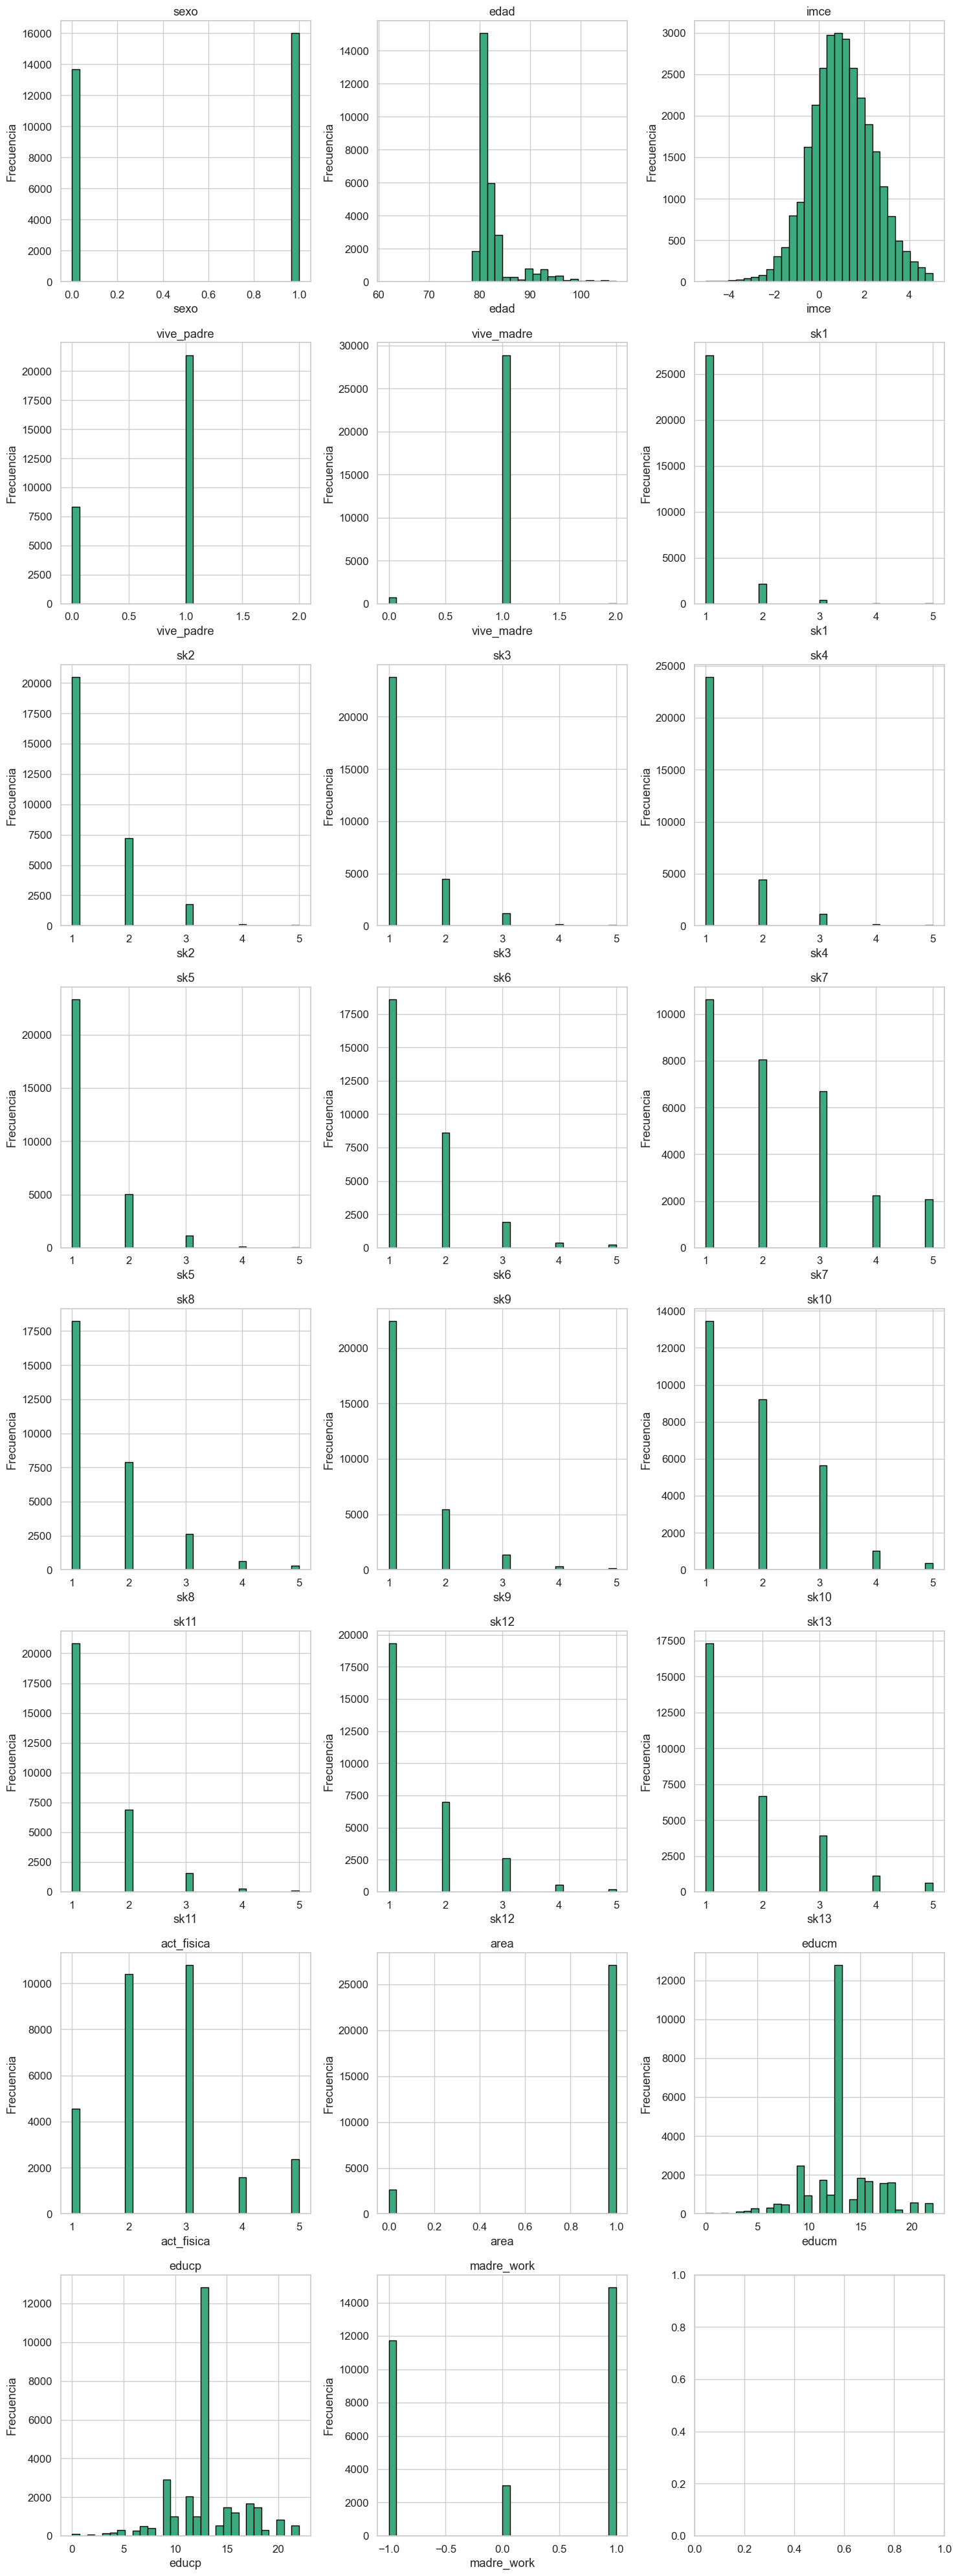

In [667]:
numerical_columns = df.select_dtypes(include='number').columns;
num_columns = len(numerical_columns);
fig, axs = plt.subplots((num_columns + 2) // 3, 3, figsize=(15, (num_columns + 2) // 3 * 5));
for i, column in enumerate(numerical_columns):
    ax = axs[i // 3, i % 3];
    ax.hist(df[column], bins=30, color='#3CA97E', edgecolor='black');
    ax.set_title(f'{column}');
    ax.set_xlabel(column);
    ax.set_ylabel('Frecuencia');
plt.tight_layout();
plt.show()

In [668]:
data0 = df.copy()
data_sk_sk7 = data0[["sk"+str(i) for i in range(1, 14)]];
data_sk = data_sk_sk7.drop("sk7", axis=1)



In [669]:
palette = {1: "blue", 0: "red",-1: "green"};

In [670]:
data_sk

,sk1,sk2,sk3,sk4,sk5,sk6,sk8,sk9,sk10,sk11,sk12,sk13
1,1,1,1,1,1,1,1,1,1,1,1,1
3,1,1,1,1,1,1,1,1,1,1,1,1
4,1,1,1,1,1,1,1,1,1,1,1,1
5,1,2,1,1,1,1,1,1,1,1,1,1
6,1,1,1,2,2,2,2,3,3,3,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...
31050,1,3,1,2,2,1,3,2,2,2,1,1
31051,1,1,2,2,1,1,2,1,3,2,1,4
31052,1,1,1,1,1,1,1,1,3,1,1,1
31053,1,1,1,1,2,2,2,1,2,1,1,2


Parte 2

In [671]:
efa = FactorAnalyzer(rotation='varimax').fit(data_sk);
np.set_printoptions(suppress=True, formatter={'float_kind':'{:f}'.format})
efa.loadings_

array([[0.174841, 0.548195, 0.120534],
       [0.184364, 0.526839, 0.320694],
       [0.180408, 0.589673, 0.148862],
       [0.197244, 0.688252, 0.175895],
       [0.123231, 0.227225, 0.758978],
       [0.179168, 0.225624, 0.440862],
       [0.280362, 0.114328, 0.466153],
       [0.499531, 0.211997, 0.184684],
       [0.559231, 0.126959, 0.107675],
       [0.669339, 0.214191, 0.180514],
       [0.525805, 0.113139, 0.133111],
       [0.482427, 0.155489, 0.119697]])

In [672]:
efa.get_eigenvalues()[0]

array([4.003739, 1.347633, 1.089935, 0.802648, 0.743580, 0.706589,
       0.691043, 0.610450, 0.531272, 0.519068, 0.491722, 0.462321])

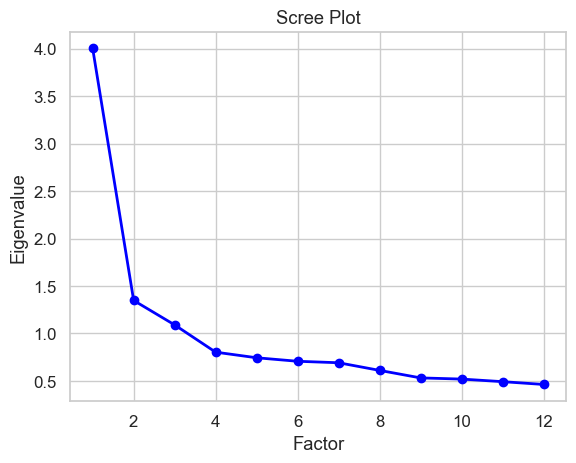

In [673]:
values = np.arange(1,13);
eigenvalues = pd.DataFrame(data=efa.get_eigenvalues());
plt.plot(values, eigenvalues.loc[0], 'o-', linewidth=2, color='blue');
plt.title('Scree Plot')
plt.xlabel('Factor')
plt.ylabel('Eigenvalue')
plt.show()

In [674]:
efa1 = FactorAnalyzer(n_factors=3, rotation='oblimin')
efa1.fit(data_sk)


factor_scores = efa1.transform(data_sk)  # Esto da las puntuaciones de cada factor
factor_df = pd.DataFrame(data=factor_scores, columns=['EF1', 'EF2', 'EF3'])
defa = pd.merge(data0, factor_df, left_index=True, right_index=True);
defa.head()


,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk12,sk13,act_fisica,area,educm,educp,madre_work,EF1,EF2,EF3
1,0,76,0.71,0,1,1,1,1,1,1,...,1,1,5.0,0,8.0,8,1,-0.867466,-0.616281,-0.638919
3,1,84,2.05,1,1,1,1,1,1,1,...,1,1,2.0,1,16.0,12,-1,-0.811243,-0.285673,-0.452383
4,0,86,1.05,1,1,1,1,1,1,1,...,1,1,1.0,1,17.0,15,0,1.825799,0.618602,1.100493
5,0,74,1.39,1,1,1,2,1,1,1,...,1,1,4.0,0,8.0,8,-1,2.453864,0.837530,3.048812
6,1,91,2.75,1,1,1,1,1,2,2,...,2,2,2.0,1,20.0,19,1,1.744281,1.583105,0.074469


In [675]:
efa1.loadings_

array([[0.025091, 0.592769, -0.036490],
       [0.014132, 0.504176, 0.201440],
       [0.015141, 0.633897, -0.014981],
       [0.001552, 0.742733, -0.011935],
       [-0.030999, 0.020518, 0.804761],
       [0.081477, 0.098873, 0.419382],
       [0.231480, -0.072300, 0.454024],
       [0.502530, 0.074356, 0.049459],
       [0.610043, -0.023017, -0.033028],
       [0.704005, 0.033629, 0.005354],
       [0.570888, -0.038834, 0.007890],
       [0.508570, 0.028714, -0.008627]])

In [676]:
efa.get_factor_variance()

(array([1.781394, 1.659008, 1.268511]),
 array([0.148450, 0.138251, 0.105709]),
 array([0.148450, 0.286700, 0.392409]))

parte 3

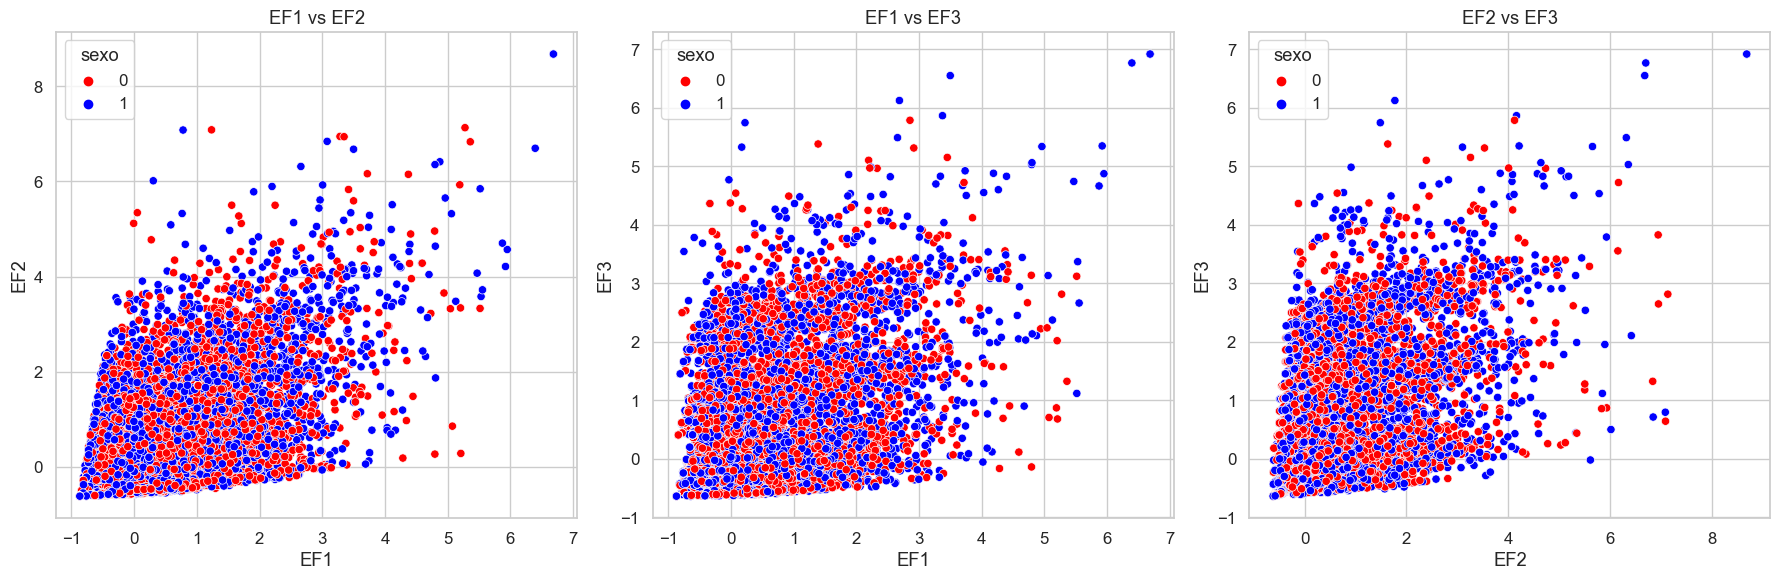

In [677]:
d = "sexo";
fig, axs = plt.subplots(1, 3, figsize=(18, 6));

#Graficar PC1 vs PC2
sns.scatterplot(data=defa, x='EF1', y='EF2', hue=d,palette=palette, ax=axs[0]);
axs[0].set_title('EF1 vs EF2');
axs[0].set_xlabel('EF1');
axs[0].set_ylabel('EF2');

#Graficar PC1 vs PC3
sns.scatterplot(data=defa, x='EF1', y='EF3', hue=d,palette=palette, ax=axs[1]);
axs[1].set_title('EF1 vs EF3');
axs[1].set_xlabel('EF1');
axs[1].set_ylabel('EF3');

#Graficar PC2 vs PC3
sns.scatterplot(data=defa, x='EF2', y='EF3', hue=d, palette=palette,ax=axs[2]);
axs[2].set_title('EF2 vs EF3');
axs[2].set_xlabel('EF2');
axs[2].set_ylabel('EF3');

plt.tight_layout();
plt.show()

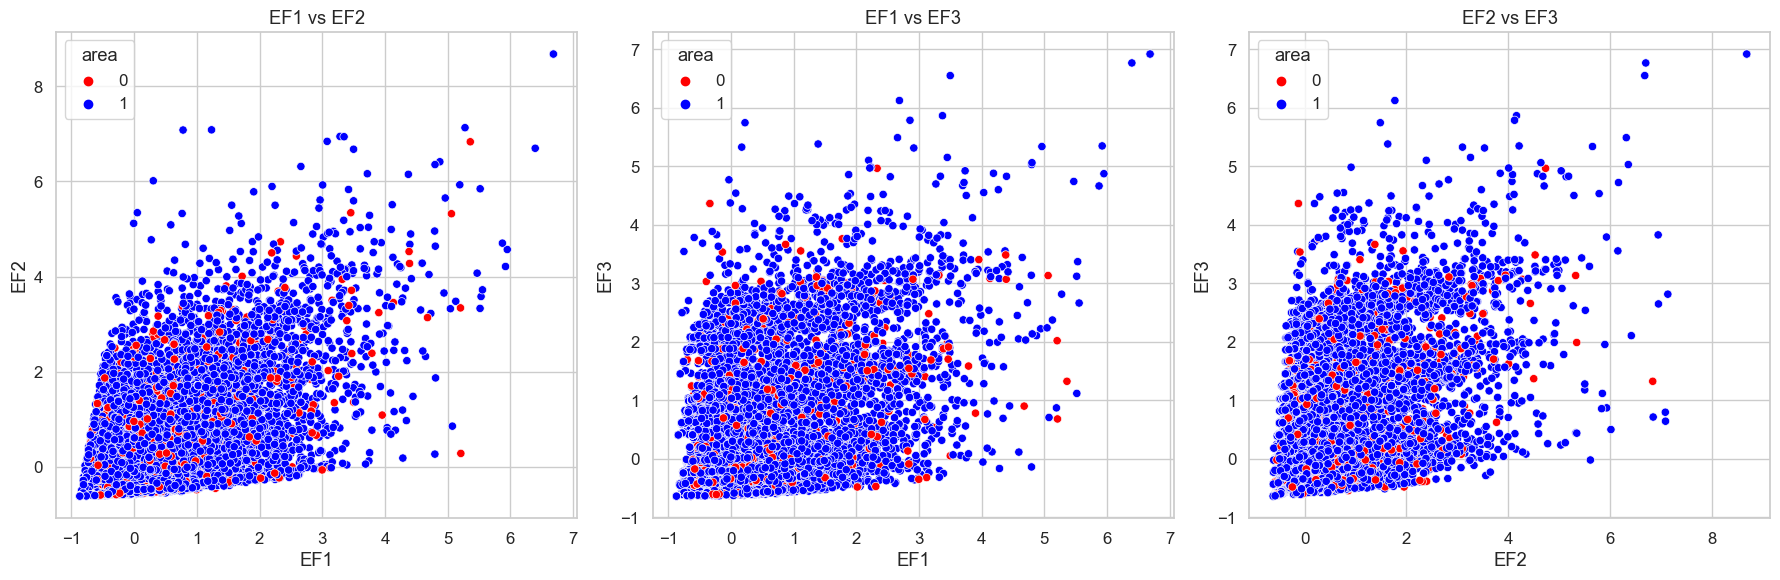

In [678]:
d = "area";
fig, axs = plt.subplots(1, 3, figsize=(18, 6));

#Graficar PC1 vs PC2
sns.scatterplot(data=defa, x='EF1', y='EF2', hue=d,palette=palette, ax=axs[0]);
axs[0].set_title('EF1 vs EF2');
axs[0].set_xlabel('EF1');
axs[0].set_ylabel('EF2');

#Graficar PC1 vs PC3
sns.scatterplot(data=defa, x='EF1', y='EF3', hue=d,palette=palette, ax=axs[1]);
axs[1].set_title('EF1 vs EF3');
axs[1].set_xlabel('EF1');
axs[1].set_ylabel('EF3');

#Graficar PC2 vs PC3
sns.scatterplot(data=defa, x='EF2', y='EF3', hue=d,palette=palette, ax=axs[2]);
axs[2].set_title('EF2 vs EF3');
axs[2].set_xlabel('EF2');
axs[2].set_ylabel('EF3');

plt.tight_layout();
plt.show()

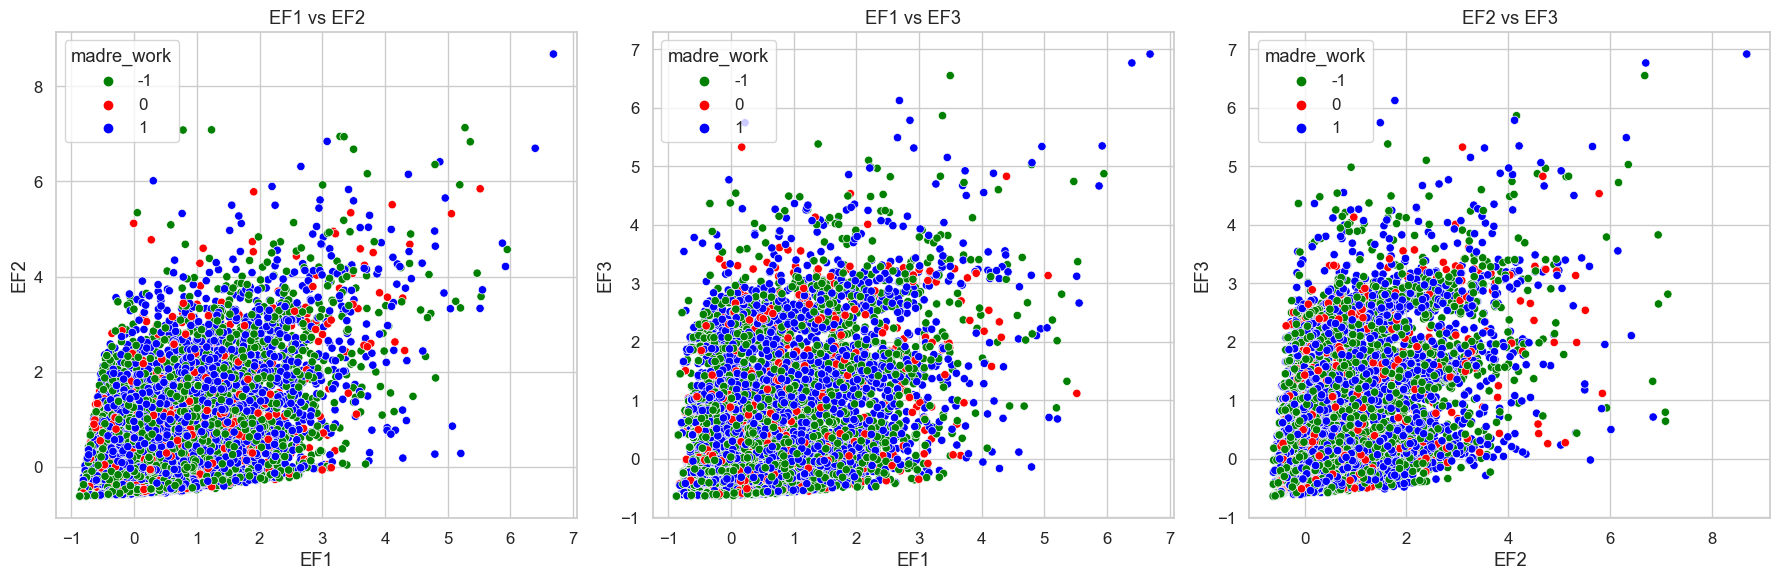

In [679]:
d = "madre_work";
fig, axs = plt.subplots(1, 3, figsize=(18, 6));


#Graficar PC1 vs PC2
sns.scatterplot(data=defa, x='EF1', y='EF2', hue=d,palette=palette, ax=axs[0]);
axs[0].set_title('EF1 vs EF2');
axs[0].set_xlabel('EF1');
axs[0].set_ylabel('EF2');

#Graficar PC1 vs PC3
sns.scatterplot(data=defa, x='EF1', y='EF3', hue=d,palette=palette, ax=axs[1]);
axs[1].set_title('EF1 vs EF3');
axs[1].set_xlabel('EF1');
axs[1].set_ylabel('EF3');

#Graficar PC2 vs PC3
sns.scatterplot(data=defa, x='EF2', y='EF3', hue=d,palette=palette, ax=axs[2]);
axs[2].set_title('EF2 vs EF3');
axs[2].set_xlabel('EF2');
axs[2].set_ylabel('EF3');

plt.tight_layout();
plt.show()

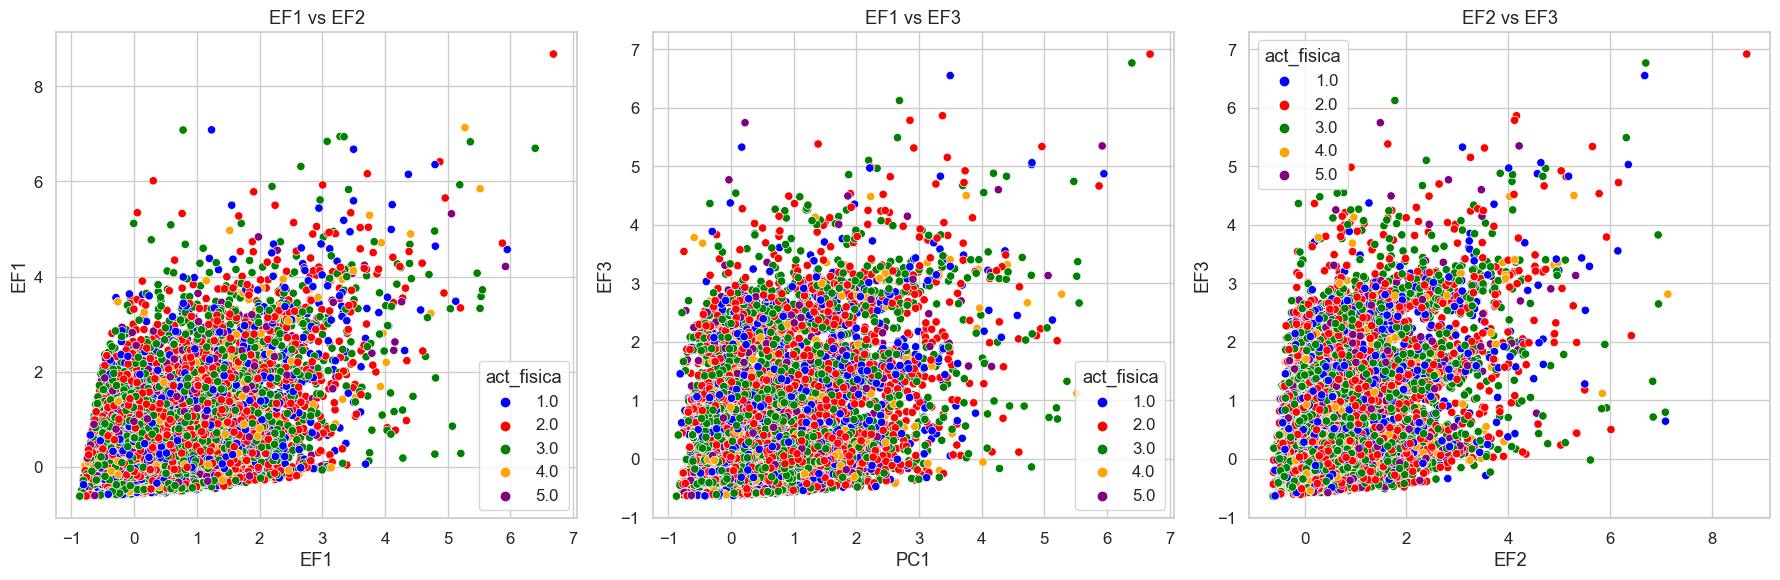

In [680]:
d = "act_fisica";
fig, axs = plt.subplots(1, 3, figsize=(18, 6));
pallete_acfisica=  {1.0: "blue", 2.0: "red",3.0: "green",4.0: "orange",5.0: "purple"};
#Graficar PC1 vs PC2
sns.scatterplot(data=defa, x='EF1', y='EF2', hue=d,palette=pallete_acfisica, ax=axs[0]);
axs[0].set_title('EF1 vs EF2');
axs[0].set_xlabel('EF1');
axs[0].set_ylabel('EF1');

#Graficar PC1 vs PC3
sns.scatterplot(data=defa, x='EF1', y='EF3', hue=d,palette=pallete_acfisica, ax=axs[1]);
axs[1].set_title('EF1 vs EF3');
axs[1].set_xlabel('PC1');
axs[1].set_ylabel('EF3');

#Graficar PC2 vs PC3
sns.scatterplot(data=defa, x='EF2', y='EF3', hue=d,palette=pallete_acfisica, ax=axs[2]);
axs[2].set_title('EF2 vs EF3');
axs[2].set_xlabel('EF2');
axs[2].set_ylabel('EF3');

plt.tight_layout();
plt.show()

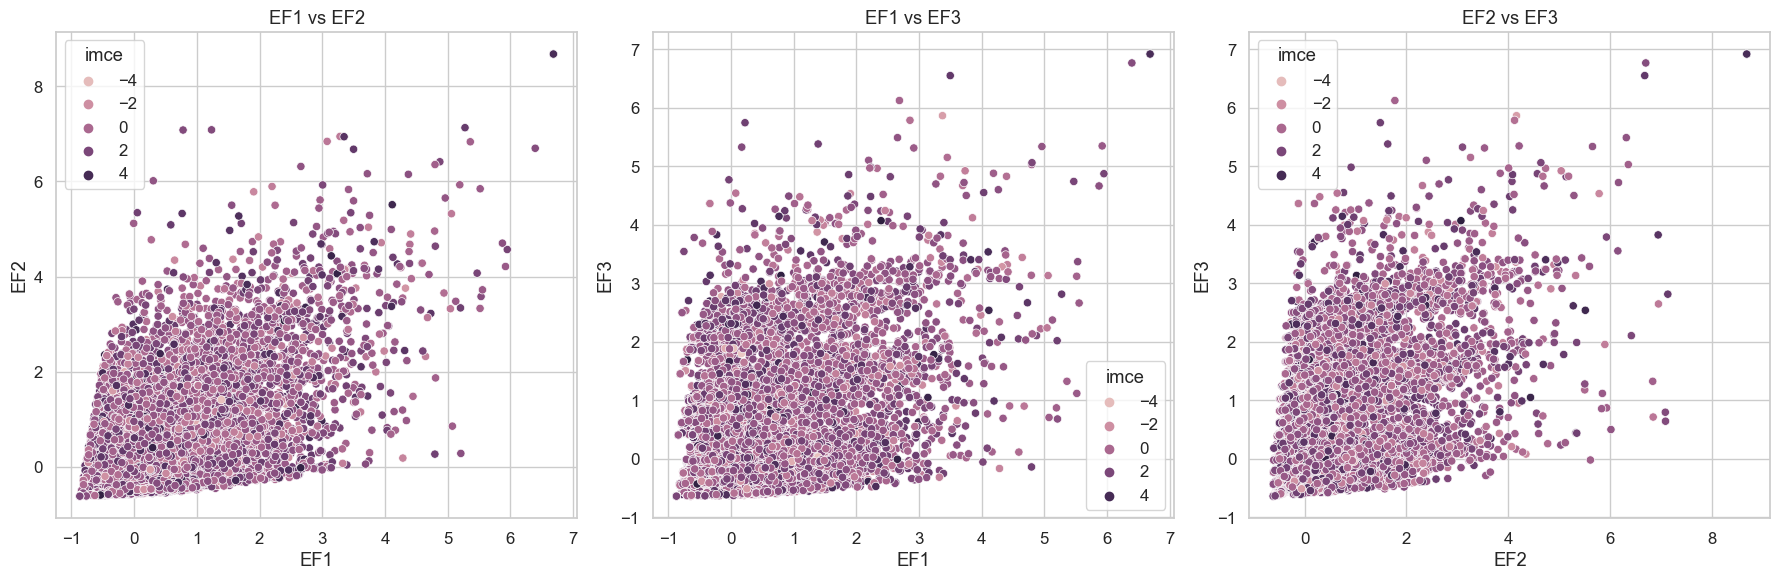

In [681]:
d = "imce"
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# EF1 vs EF2
sns.scatterplot(data=defa, x='EF1', y='EF2', hue=d, ax=axs[0])
axs[0].set_title('EF1 vs EF2')
axs[0].set_xlabel('EF1')
axs[0].set_ylabel('EF2')  # Esto estaba mal en tu código original

# EF1 vs EF3
sns.scatterplot(data=defa, x='EF1', y='EF3', hue=d, ax=axs[1])
axs[1].set_title('EF1 vs EF3')
axs[1].set_xlabel('EF1')
axs[1].set_ylabel('EF3')

# EF2 vs EF3
sns.scatterplot(data=defa, x='EF2', y='EF3', hue=d, ax=axs[2])
axs[2].set_title('EF2 vs EF3')
axs[2].set_xlabel('EF2')
axs[2].set_ylabel('EF3')

plt.tight_layout()
plt.show()


parte 4

In [682]:
print(semopy.efa.explore_cfa_model(data_sk, pval=0.05));

eta1 =~ sk11 + sk9 + sk10 + sk12
eta2 =~ sk4 + sk2 + sk11 + sk5 + sk3 + sk9 + sk1 + sk6 + sk8 + sk12
eta3 =~ sk11 + sk12 + sk13



In [683]:
mod = """
eta1 =~ sk9+ sk10 + sk11 + sk12 + sk13 #Desarrollo Cognitivo y Exploratorio
eta2 =~ sk1+ sk2 + sk3 +sk4  #Expresión Emocional y Afectiva
eta3 =~ sk5 + sk6 + sk8  #Habilidades Sociales y Cooperación
"""

model = semopy.Model(mod);
model.fit(data_sk)
out = model.fit(data_sk);
print(out);



Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.143
Number of iterations: 1
Params: 1.348 1.248 1.097 1.274 1.877 1.646 1.846 1.020 1.158 0.152 0.051 0.091 0.049 0.161 0.057 0.095 0.595 0.200 0.442 0.713 0.242 0.199 0.158 0.151 0.372 0.469 0.277


In [684]:

factor_scores = model.predict_factors(data_sk)
factor_df = pd.DataFrame(data=factor_scores, columns=['eta1', 'eta2', 'eta3'])
dcfa = pd.merge(data0, factor_df, left_index=True, right_index=True);
dcfa.head()


,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk12,sk13,act_fisica,area,educm,educp,madre_work,eta1,eta2,eta3
1,0,76,0.71,0,1,1,1,1,1,1,...,1,1,5.0,0,8.0,8,1,-0.328169,-0.145736,-0.294812
3,1,84,2.05,1,1,1,1,1,1,1,...,1,1,2.0,1,16.0,12,-1,-0.303187,-0.062790,-0.256423
4,0,86,1.05,1,1,1,1,1,1,1,...,1,1,1.0,1,17.0,15,0,0.756819,0.129280,0.476656
5,0,74,1.39,1,1,1,2,1,1,1,...,1,1,4.0,0,8.0,8,-1,0.939979,0.248456,1.144751
6,1,91,2.75,1,1,1,1,1,2,2,...,2,2,2.0,1,20.0,19,1,0.700089,0.336961,0.178982


In [685]:
model.predict_factors(data_sk)

,eta1,eta2,eta3
0,-0.328169,-0.145736,-0.294812
1,-0.328169,-0.145736,-0.294812
2,-0.328169,-0.145736,-0.294812
3,-0.303187,-0.062790,-0.256423
4,0.756819,0.129280,0.476656
...,...,...,...
29691,0.247930,0.241069,0.432757
29692,0.300915,0.131515,0.020204
29693,-0.174141,-0.131148,-0.264774
29694,-0.111973,-0.074129,0.256844


In [686]:
model.inspect(mode='list', what="names", std_est=True)

,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk9,~,eta1,1.000000,0.594428,-,-,-
1,sk10,~,eta1,1.348295,0.562598,0.01854,72.72513,0.0
2,sk11,~,eta1,1.247906,0.736004,0.014736,84.684346,0.0
3,sk12,~,eta1,1.097331,0.540704,0.015523,70.692807,0.0
4,sk13,~,eta1,1.273586,0.506376,0.018913,67.339331,0.0
5,sk1,~,eta2,1.000000,0.582663,-,-,-
6,sk2,~,eta2,1.876642,0.644555,0.023793,78.873561,0.0
7,sk3,~,eta2,1.646084,0.631822,0.021121,77.936233,0.0
8,sk4,~,eta2,1.845636,0.715788,0.022168,83.255093,0.0
9,sk5,~,eta3,1.000000,0.718118,-,-,-


In [687]:
semopy.calc_stats(model)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,51,66,4252.869291,0.0,80903.16637,0.948021,0.947433,0.931972,0.947433,0.932733,0.052674,53.713573,277.780299,0.143214


Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.143
Number of iterations: 41
Params: 1.348 1.248 1.097 1.274 1.877 1.646 1.846 1.020 1.158 0.152 0.051 0.091 0.049 0.161 0.057 0.095 0.595 0.200 0.442 0.713 0.242 0.199 0.158 0.151 0.372 0.469 0.277


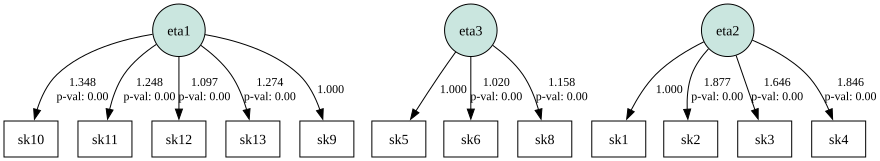

In [688]:
model = semopy.Model(mod)
out = model.fit(data_sk)
print(out)
semopy.semplot(model, "modelo_lindo.png")

parte 5

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:01<00:00,  1.43s/it, max_LL=-5.18e+4, max_avg_LL=-1.74]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:03<00:00,  3.73s/it, max_LL=-5.14e+4, max_avg_LL=-1.73]


Fitting StepMix...


...

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:14<00:00, 14.12s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]
c:\Users\vicen\anaconda3\lib\site-packages\stepmix\stepmix.py:968: ConvergenceWarning: Initializations did not converge. Try different init parameters, or increase max_iter, abs_tol, rel_tol or check for degenerate data.
  warnings.warn(


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:16<00:00, 16.60s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]
c:\Users\vicen\anaconda3\lib\site-packages\stepmix\stepmix.py:968: ConvergenceWarning: Initializations did not converge. Try different init parameters, or increase max_iter, abs_tol, rel_tol or check for degenerate data.
  warnings.warn(


<Axes: >

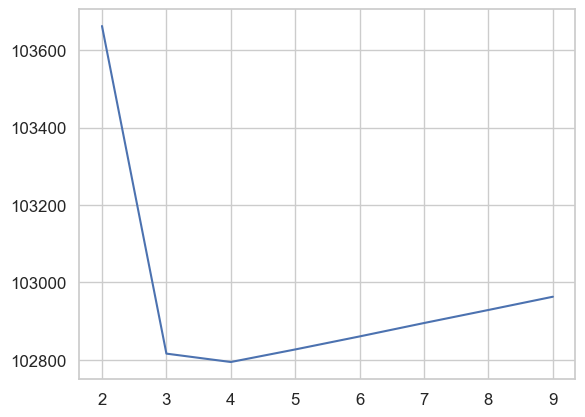

In [689]:

from stepmix import StepMix

df2=df[['imce']]
# Numero optimo de clusters CLASES LATENTES
K = range(2, 10)
fits = []
BIC = []

for k in K:
    # train the model for current value of k on training data
    model = StepMix(n_components=k, measurement='gaussian', verbose=0, random_state=123).fit(df2)
    
    # append the model to fits
    fits.append(model)
    
    # Append the silhouette score to scores
    BIC.append(model.sabic(df2))

sns.lineplot(x = K, y = BIC)    


In [690]:
# Ajustar modelo con 3 clases
df3 = df2.copy()

model3 = StepMix(n_components=3, measurement="gaussian", verbose=1, random_state=123)
model3.fit(df3)

# Ajustar modelo con 3 clases
model4 = StepMix(n_components=4, measurement="gaussian", verbose=1, random_state=123)
model4.fit(df3)

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:03<00:00,  3.63s/it, max_LL=-5.14e+4, max_avg_LL=-1.73]


MODEL REPORT
    Measurement model parameters
          model_name     gaussian_unit                
          class_no                   0       1       2
          param variable                              
          means imce            -1.949  2.4056  0.5984
    Class weights
        Class 1 : 0.02
        Class 2 : 0.27
        Class 3 : 0.71
    Fit for 3 latent classes
    Estimation method             : 1-step
    Number of observations        : 29696
    Number of latent classes      : 3
    Number of estimated parameters: 5
    Log-likelihood (LL)           : -51364.3251
    -2LL                          : 102728.6503
    Average LL                    : -1.7297
    AIC                           : 102738.65
    BIC                           : 102780.14
    CAIC                          : 102785.14
    Sample-Size Adjusted BIC      : 102815.75
    Entropy                       : 11499.4902
    Scaled Relative Entropy       : 0.6475
Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:08<00:00,  8.69s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]

MODEL REPORT
    Measurement model parameters
          model_name     gaussian_unit                        
          class_no                   0       1       2       3
          param variable                                      
          means imce             1.173  2.7111 -2.5822  0.1384
    Class weights
        Class 1 : 0.49
        Class 2 : 0.16
        Class 3 : 0.01
        Class 4 : 0.35
    Fit for 4 latent classes
    Estimation method             : 1-step
    Number of observations        : 29696
    Number of latent classes      : 4
    Number of estimated parameters: 7
    Log-likelihood (LL)           : -51336.0764
    -2LL                          : 102672.1527
    Average LL                    : -1.7287
    AIC                           : 102686.15
    BIC                           : 102744.24
    CAIC                          : 102751.24
    Sample-Size Adjusted BIC      : 102794.09
    Entropy                       : 22265.7966
    Scaled Relative Entropy    


c:\Users\vicen\anaconda3\lib\site-packages\stepmix\stepmix.py:968: ConvergenceWarning: Initializations did not converge. Try different init parameters, or increase max_iter, abs_tol, rel_tol or check for degenerate data.
  warnings.warn(


StepMix(measurement='gaussian', n_components=4, random_state=123, verbose=1)

In [691]:
# Ajustar modelo con 3 clases
model = StepMix(n_components=3, measurement="gaussian", verbose=1, random_state=123)
model.fit(df2)
df2['Predict'] = model.predict(df2)



Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:03<00:00,  3.58s/it, max_LL=-5.14e+4, max_avg_LL=-1.73]

MODEL REPORT
    Measurement model parameters
          model_name     gaussian_unit                
          class_no                   0       1       2
          param variable                              
          means imce            -1.949  2.4056  0.5984
    Class weights
        Class 1 : 0.02
        Class 2 : 0.27
        Class 3 : 0.71
    Fit for 3 latent classes
    Estimation method             : 1-step
    Number of observations        : 29696
    Number of latent classes      : 3
    Number of estimated parameters: 5
    Log-likelihood (LL)           : -51364.3251
    -2LL                          : 102728.6503
    Average LL                    : -1.7297
    AIC                           : 102738.65
    BIC                           : 102780.14
    CAIC                          : 102785.14
    Sample-Size Adjusted BIC      : 102815.75
    Entropy                       : 11499.4902
    Scaled Relative Entropy       : 0.6475



C:\Users\vicen\AppData\Local\Temp\ipykernel_24248\3116879115.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['Predict'] = model.predict(df2)


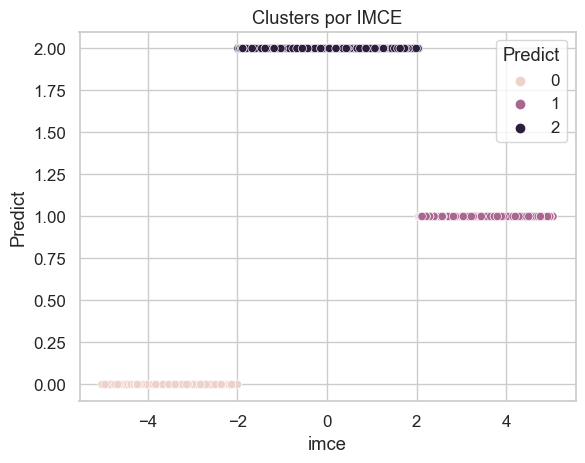

In [692]:
sns.scatterplot(data=df2, x='imce', y='Predict', hue='Predict')
plt.title('Clusters por IMCE')
plt.show()

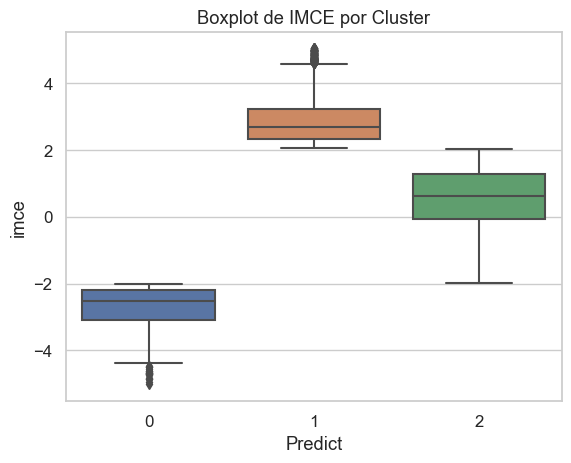

In [693]:
sns.boxplot(data=df2, x='Predict', y='imce')
plt.title('Boxplot de IMCE por Cluster')
plt.show()

parte 6

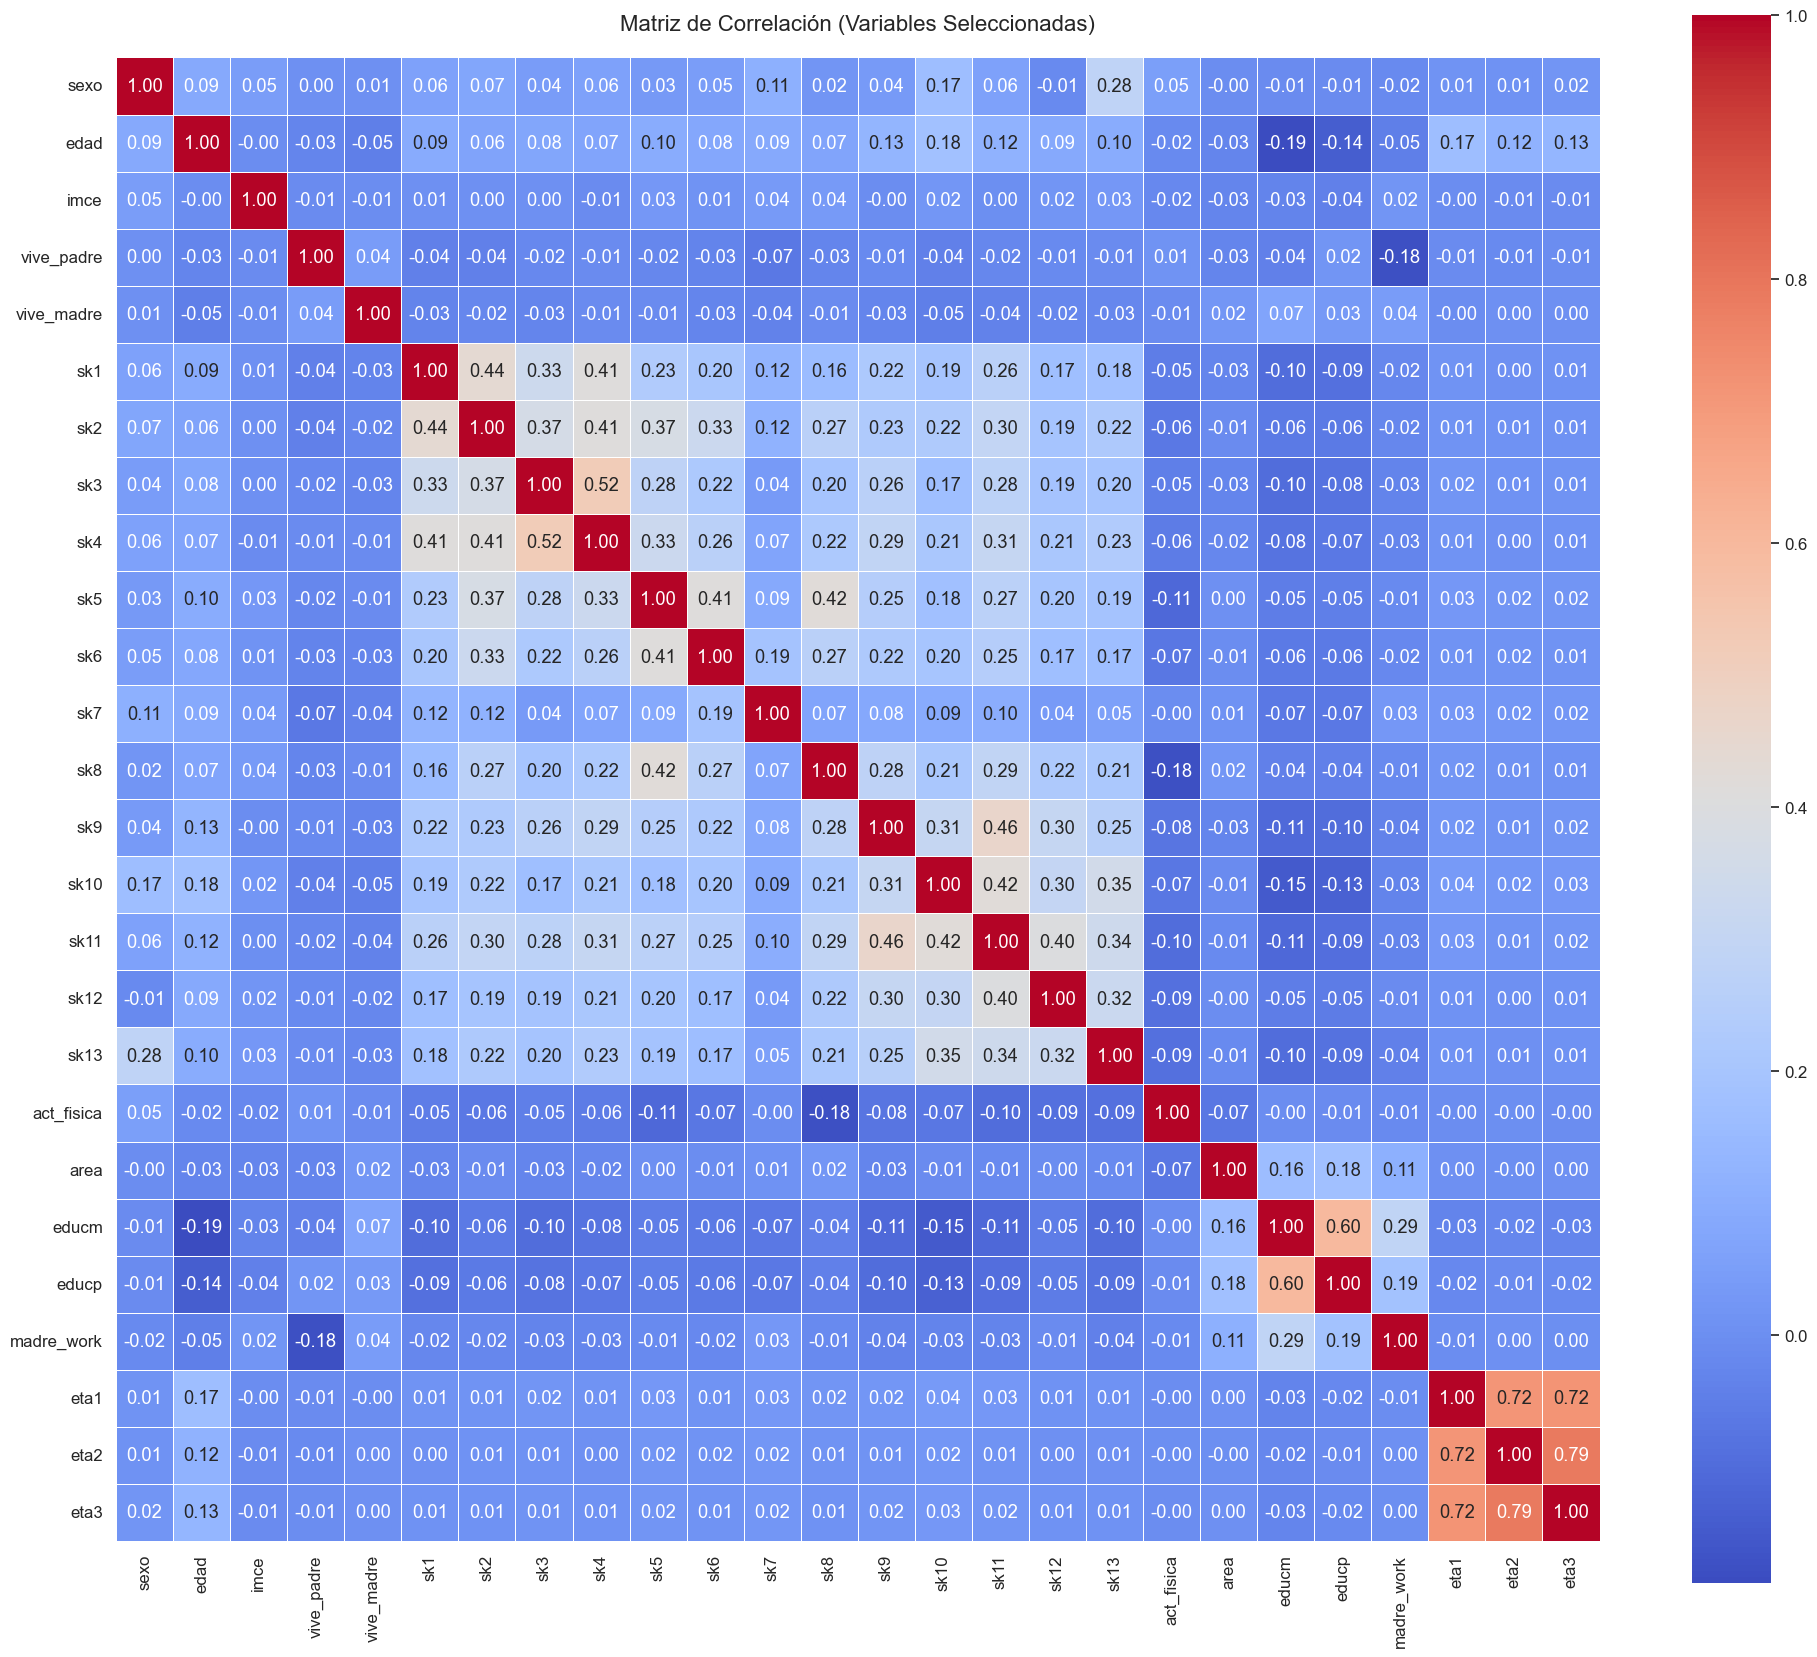

In [694]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



# Crear la matriz de correlación
matriz_correlacion = dcfa.corr()

# Configurar estilo visual
sns.set(style='whitegrid', font_scale=1.1)

# Dibujar heatmap
plt.figure(figsize=(20, 20))
sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Matriz de Correlación (Variables Seleccionadas)", fontsize=16, pad=20)
plt.tight_layout()
plt.show()


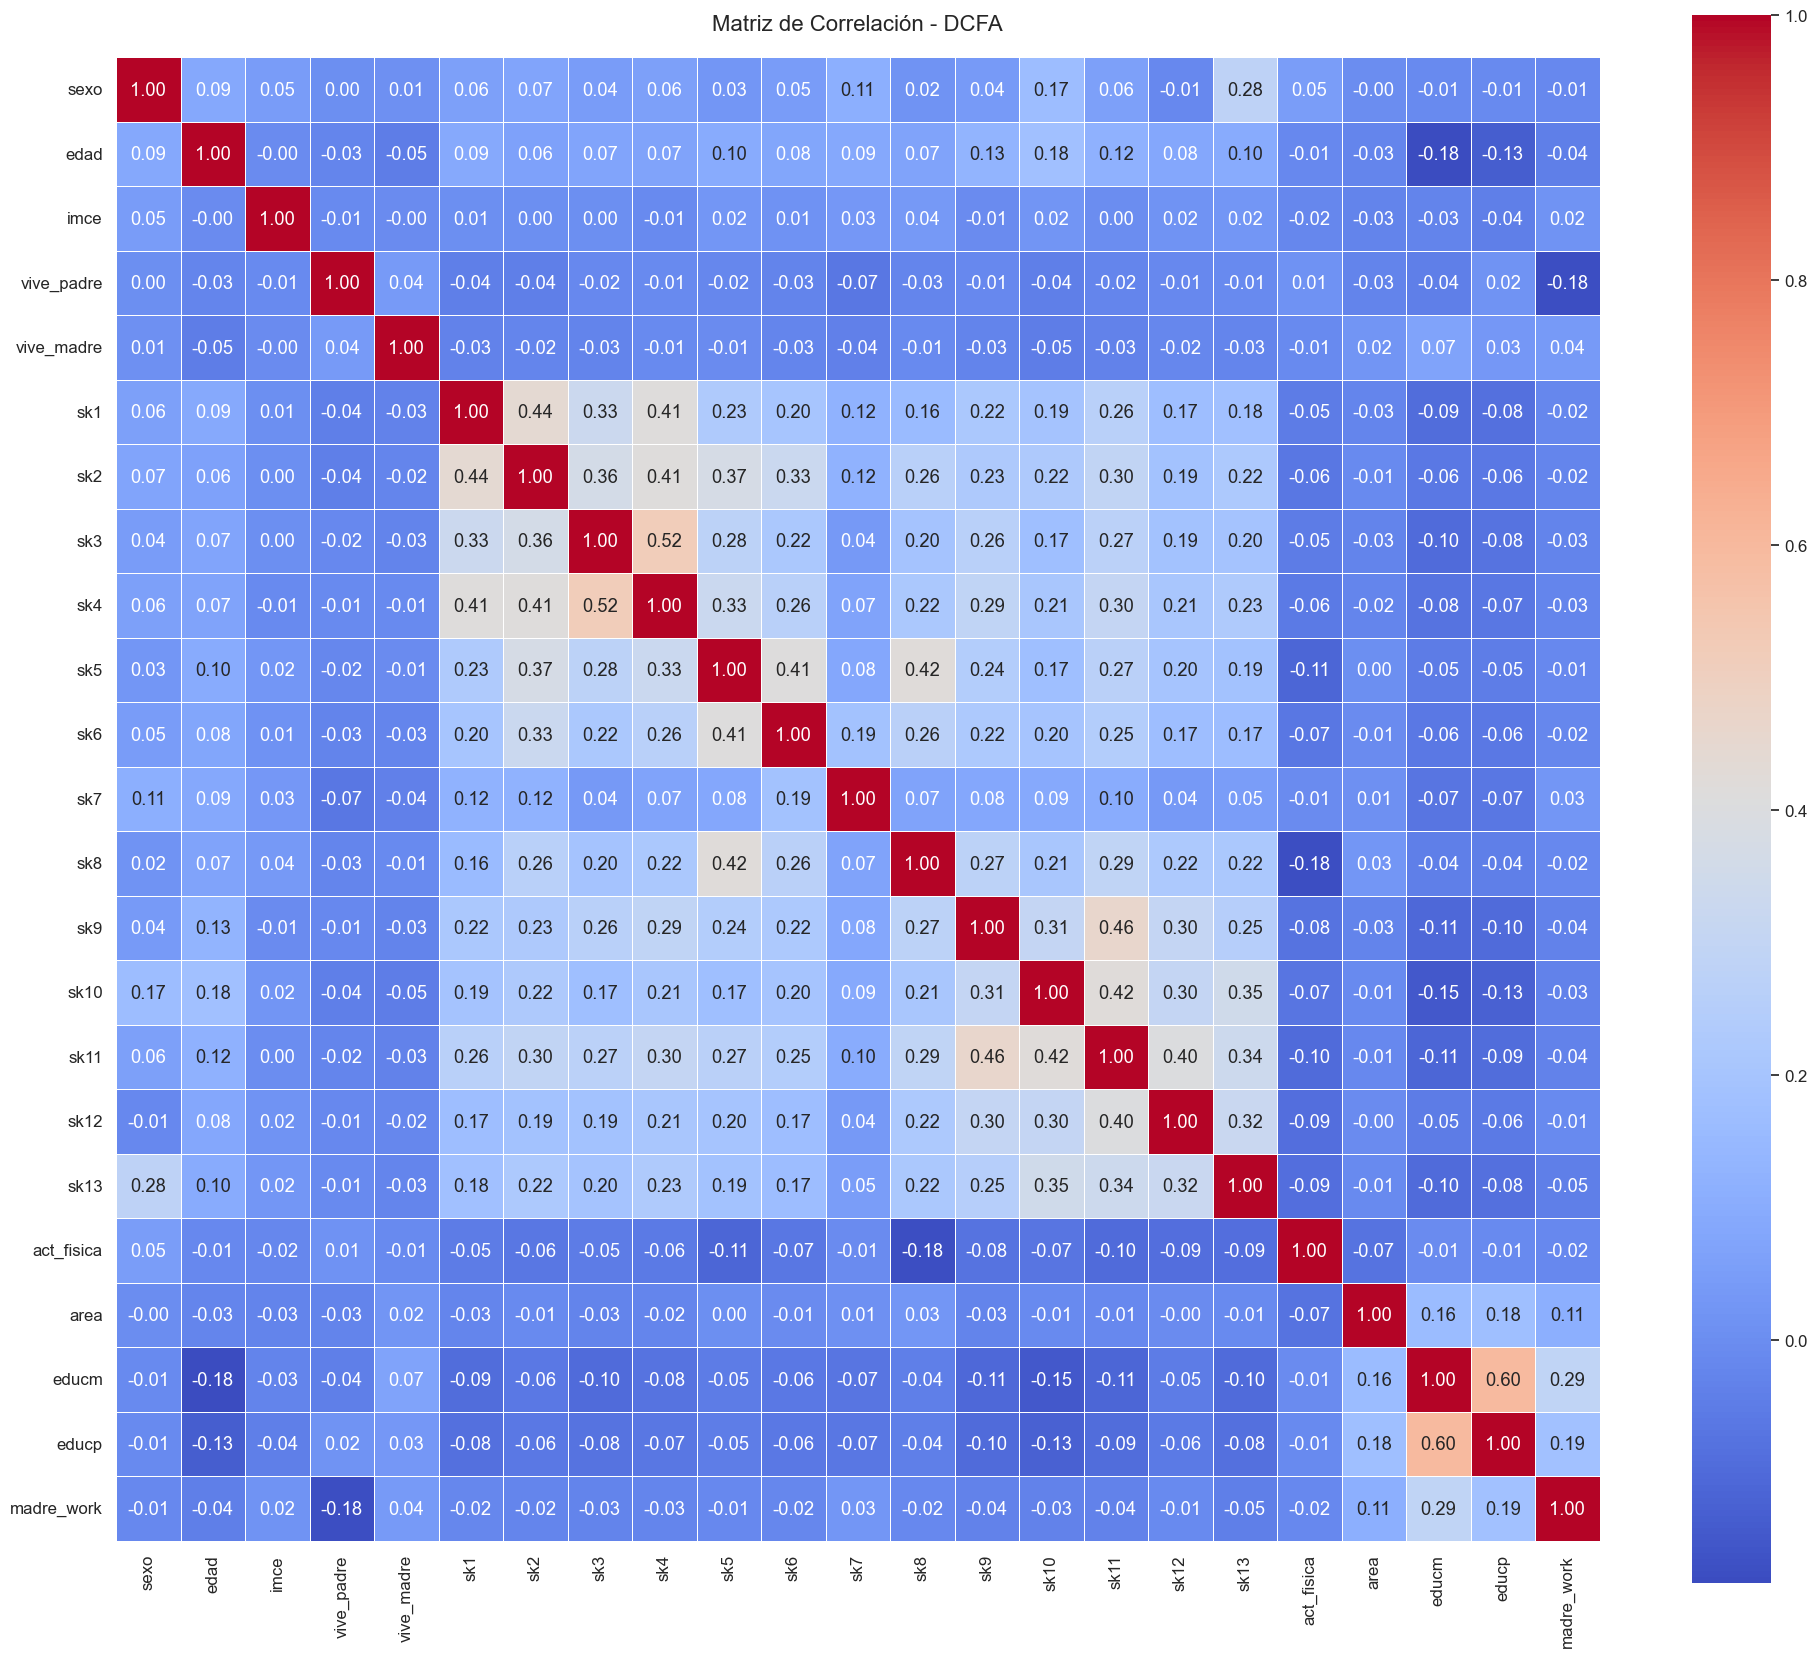

In [695]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Supongamos que ya tienes el DataFrame 'dcfa'
# Crear la matriz de correlación
matriz_correlacion = df.corr()

# Configurar el estilo gráfico
sns.set(style='whitegrid', font_scale=1.1)

# Crear el heatmap
plt.figure(figsize=(20, 20))  # Puedes ajustar el tamaño según lo necesario
heatmap = sns.heatmap(
    matriz_correlacion, 
    annot=True,        # Muestra los valores dentro de cada celda
    fmt=".2f",         # Formato de los números
    cmap='coolwarm',   # Colores: puedes probar también 'viridis', 'magma', etc.
    square=True,       # Celdas cuadradas
    linewidths=.5,     # Líneas divisorias entre celdas
    cbar_kws={"shrink": .8}  # Barra de color más pequeña
)

# Título del gráfico
plt.title("Matriz de Correlación - DCFA", fontsize=16, pad=20)

# Mostrar el gráfico
plt.tight_layout()
plt.show()

In [696]:
mod_cf = '''
eta1 =~ sk9+ sk10 + sk11 + sk12 + sk13
eta2 =~ sk1+ sk2 + sk3 +sk4 
eta3 =~ sk5 + sk6 + sk8  

imce =~ eta1 + eta2 + eta3 
eta1 ~ educm  + edad 
eta3 ~ act_fisica+edad
eta2 ~ educm+edad
educm~ madre_work + area + educp  +vive_padre
'''

model_cfa = semopy.Model(mod_cf);
out = model_cfa.fit(data0);
print(out)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.219
Number of iterations: 50
Params: 1.363 1.236 1.086 1.272 1.877 1.650 1.847 1.017 1.181 0.651 1.126 -0.014 0.016 -0.044 0.012 -0.005 0.005 0.632 0.498 0.541 -0.143 6.753 0.069 0.016 0.057 0.074 0.095 0.587 0.203 0.445 0.712 0.242 0.199 0.158 0.153 0.375 0.463 0.277


In [697]:
semopy.calc_stats(model_cfa)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,152,177,6492.077513,0.0,103550.943005,0.938669,0.937305,0.926994,0.937305,0.928581,0.037479,75.562764,390.915934,0.218618


In [ ]:
model_cfa.inspect(mode='list', what="names", std_est=True)

     lval  op        rval  Estimate  Est. Std  Std. Err     z-value   p-value
0    eta1   ~        imce  1.000000  0.700479         -           -         -
1    eta2   ~        imce  0.650704  0.805094  0.012575   51.746612       0.0
2    eta3   ~        imce  1.125952  0.775193  0.020059   56.131228       0.0
3    eta1   ~       educm -0.013917 -0.119152  0.000722  -19.282807       0.0
4    eta1   ~        edad  0.016277  0.179829  0.000615   26.462019       0.0
5    eta3   ~  act_fisica -0.044322 -0.119668  0.002287  -19.377545       0.0
6    eta3   ~        edad  0.012185  0.132312  0.000655    18.60197       0.0
7    eta2   ~       educm -0.005491 -0.083034    0.0004   -13.73056       0.0
8    eta2   ~        edad  0.004919  0.095993  0.000346    14.21938       0.0
9   educm   ~  madre_work  0.631750  0.178732  0.016628   37.993351       0.0
10  educm   ~        area  0.498356  0.042483  0.054169    9.200038       0.0
11  educm   ~       educp  0.540829  0.555455  0.004554  118.753

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.219
Number of iterations: 50
Params: 1.363 1.236 1.086 1.272 1.877 1.650 1.847 1.017 1.181 0.651 1.126 -0.014 0.016 -0.044 0.012 -0.005 0.005 0.632 0.498 0.541 -0.143 6.753 0.069 0.016 0.057 0.074 0.095 0.587 0.203 0.445 0.712 0.242 0.199 0.158 0.153 0.375 0.463 0.277


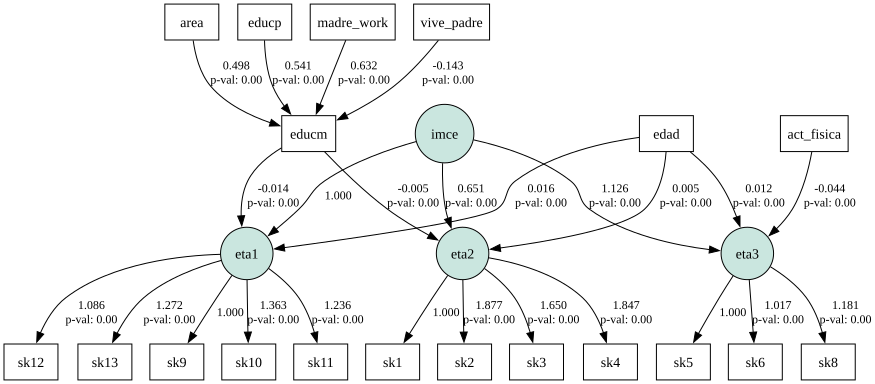

In [699]:
model_cfa = semopy.Model(mod_cf)
out = model_cfa.fit(data0)
print(out)


semopy.semplot(model_cfa, "semmodel.png")

parte7

In [700]:
import pandas as pd


data1 = pd.concat([data0, df2['Predict']], axis=1)
data1

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work,Predict
1,0,76,0.71,0,1,1,1,1,1,1,...,1,1,1,1,5.0,0,8.0,8,1,2
3,1,84,2.05,1,1,1,1,1,1,1,...,1,1,1,1,2.0,1,16.0,12,-1,1
4,0,86,1.05,1,1,1,1,1,1,1,...,1,1,1,1,1.0,1,17.0,15,0,2
5,0,74,1.39,1,1,1,2,1,1,1,...,1,1,1,1,4.0,0,8.0,8,-1,2
6,1,91,2.75,1,1,1,1,1,2,2,...,3,3,2,2,2.0,1,20.0,19,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31050,0,78,1.63,1,1,1,3,1,2,2,...,2,2,1,1,2.0,1,13.0,13,-1,2
31051,1,79,2.57,1,1,1,1,2,2,1,...,3,2,1,4,3.0,1,18.0,19,0,1
31052,0,78,2.12,1,1,1,1,1,1,1,...,3,1,1,1,3.0,1,13.0,9,1,1
31053,1,78,-0.43,1,1,1,1,1,1,2,...,2,1,1,2,2.0,1,17.0,15,1,2


In [701]:
# Obtener los valores únicos del cluster
cluster_labels = data1['Predict'].unique()

# Crear un diccionario con nombres tipo 'datac0', 'datac1', ...
data_clusters = {f"datac{label}": data1[data1['Predict'] == label] for label in cluster_labels}


In [702]:
data_clusters['datac0'].head()  # Mostrar las primeras filas del cluster 0 como ejemplo

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work,Predict
39,1,84,-2.37,1,1,1,3,1,1,1,...,3,3,1,5,5.0,1,6.0,9,-1,0
108,0,105,-3.30,1,1,2,2,2,2,2,...,2,2,2,2,2.0,1,8.0,12,-1,0
163,1,105,-3.40,1,1,1,1,1,1,2,...,3,2,2,3,3.0,0,11.0,2,-1,0
243,0,102,-3.80,0,1,1,2,2,2,2,...,3,3,3,2,1.0,1,9.0,12,0,0
451,1,98,-2.51,0,1,1,1,1,1,1,...,1,1,1,1,3.0,1,9.0,9,1,0


In [703]:
data_clusters['datac1'].head()  #

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work,Predict
3,1,84,2.05,1,1,1,1,1,1,1,...,1,1,1,1,2.0,1,16.0,12,-1,1
6,1,91,2.75,1,1,1,1,1,2,2,...,3,3,2,2,2.0,1,20.0,19,1,1
17,1,74,2.53,1,1,1,2,1,1,1,...,1,1,1,1,2.0,1,13.0,13,1,1
24,0,85,3.41,0,1,2,3,1,2,2,...,2,2,2,2,2.0,0,13.0,13,0,1
25,1,84,2.98,1,1,1,1,1,1,1,...,1,1,1,4,3.0,0,9.0,9,-1,1


In [704]:
data_clusters['datac2'].head()  #

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,...,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work,Predict
1,0,76,0.71,0,1,1,1,1,1,1,...,1,1,1,1,5.0,0,8.0,8,1,2
4,0,86,1.05,1,1,1,1,1,1,1,...,1,1,1,1,1.0,1,17.0,15,0,2
5,0,74,1.39,1,1,1,2,1,1,1,...,1,1,1,1,4.0,0,8.0,8,-1,2
7,1,92,1.53,1,1,1,3,1,1,3,...,4,3,2,4,1.0,1,13.0,11,0,2
8,1,69,1.96,1,1,1,2,3,2,1,...,4,2,2,3,2.0,0,10.0,9,1,2


Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.648
Number of iterations: 59
Params: 1.058 1.112 0.822 1.074 2.489 2.213 2.772 1.075 1.331 0.529 1.011 -0.020 0.006 -0.042 0.004 -0.007 -0.002 0.666 -0.446 0.542 0.147 6.593 0.131 0.003 0.059 0.085 0.081 0.651 0.217 0.351 0.762 0.239 0.198 0.140 0.166 0.413 0.526 0.280
       DoF  DoF Baseline        chi2  chi2 p-value  chi2 Baseline      CFI  \
Value  152           177  268.280953  1.832221e-08    1674.305151  0.92234   

            GFI      AGFI       NFI       TLI     RMSEA        AIC  \
Value  0.839766  0.813411  0.839766  0.909567  0.043039  74.703957   

              BIC    LogLik  
Value  227.686864  0.648022  
     lval  op        rval  Estimate  Est. Std  Std. Err    z-value   p-value
0    eta1   ~        imce  1.000000  0.619947         -          -         -
1    eta2   ~        imce  0.529296  0.935318  0.091383   5.792031       0.0
2    eta3 

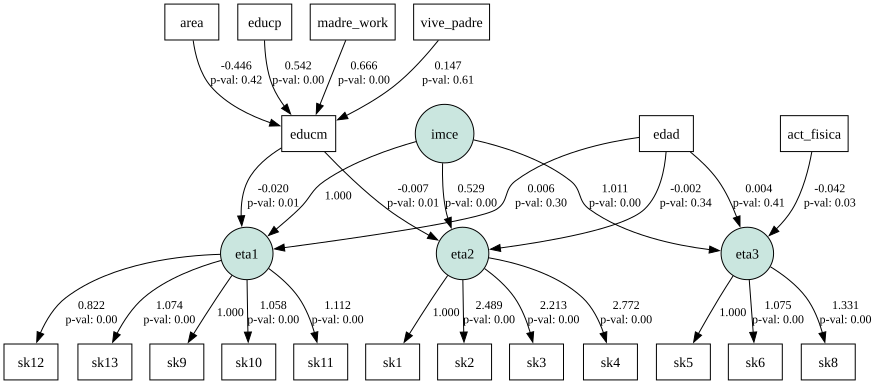

In [705]:
model_cfa_c0 = semopy.Model(mod_cf);
out = model_cfa_c0.fit(data_clusters['datac0']);
print(out)

print(semopy.calc_stats(model_cfa_c0))
print(model_cfa_c0.inspect(mode='list', what="names", std_est=True))
semopy.semplot(model_cfa_c0, "semmodel.png")

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.262
Number of iterations: 53
Params: 1.383 1.230 1.131 1.355 1.800 1.484 1.645 0.979 1.130 0.677 1.202 -0.014 0.017 -0.053 0.013 -0.006 0.007 0.643 0.511 0.514 -0.209 7.110 0.073 0.021 0.066 0.075 0.096 0.615 0.214 0.472 0.742 0.246 0.215 0.160 0.167 0.399 0.518 0.272
       DoF  DoF Baseline         chi2  chi2 p-value  chi2 Baseline       CFI  \
Value  152           177  1746.921934           0.0   23357.512994  0.931196   

            GFI      AGFI       NFI       TLI     RMSEA        AIC  \
Value  0.925209  0.912908  0.925209  0.919879  0.039639  75.476891   

              BIC    LogLik  
Value  334.132386  0.261554  
     lval  op        rval  Estimate  Est. Std  Std. Err    z-value   p-value
0    eta1   ~        imce  1.000000  0.693153         -          -         -
1    eta2   ~        imce  0.676797  0.776186  0.027527  24.586793       0.0
2    et

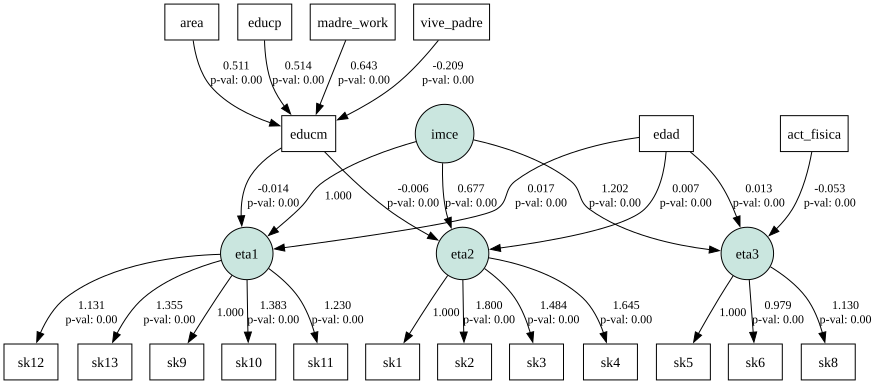

In [706]:
model_cfa_c1 = semopy.Model(mod_cf);
out = model_cfa_c1.fit(data_clusters['datac1']);
print(out)

print(semopy.calc_stats(model_cfa_c1))
print(model_cfa_c1.inspect(mode='list', what="names", std_est=True))
semopy.semplot(model_cfa_c1, "semmodel.png")

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.215
Number of iterations: 55
Params: 1.364 1.243 1.080 1.250 1.888 1.693 1.898 1.029 1.197 0.648 1.107 -0.014 0.016 -0.042 0.012 -0.005 0.005 0.629 0.507 0.548 -0.129 6.645 0.067 0.015 0.055 0.073 0.095 0.578 0.199 0.438 0.702 0.241 0.194 0.158 0.148 0.368 0.445 0.278
       DoF  DoF Baseline         chi2  chi2 p-value  chi2 Baseline       CFI  \
Value  152           177  4857.119406           0.0   78990.922841  0.940301   

           GFI      AGFI      NFI       TLI     RMSEA        AIC         BIC  \
Value  0.93851  0.928397  0.93851  0.930482  0.037008  75.570223  380.552064   

         LogLik  
Value  0.214888  
     lval  op        rval  Estimate  Est. Std  Std. Err     z-value   p-value
0    eta1   ~        imce  1.000000  0.703276         -           -         -
1    eta2   ~        imce  0.647510  0.811240  0.014358   45.096934       0.0
2    eta

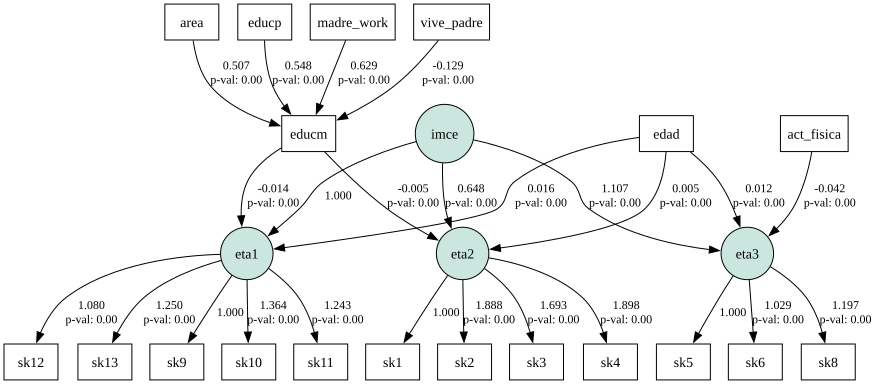

In [707]:
model_cfa_c2 = semopy.Model(mod_cf);
out = model_cfa_c2.fit(data_clusters['datac2']);
print(out)

print(semopy.calc_stats(model_cfa_c2))
print(model_cfa_c2.inspect(mode='list', what="names", std_est=True))
semopy.semplot(model_cfa_c2, "semmodel.png")